In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv("../data/processed/loan_risk_feature_engineered.csv")
df.head()

,Unnamed: 0,CustomerID,Age,Gender,MaritalStatus,Education,Occupation,EmploymentYears,AnnualIncome,MonthlyExpenses,...,FraudFlag,CustomerSegment,LoanApproved,MonthlyIncome,DisposableIncome,EMIRatio,SavingRatio,DebtToIncomeRatio,Networth,CreditUtilizationRatio
0,0,112424.0,36.0,Male,Single,PostGraduate,Salaried,25.0,6114208.0,190034.0,...,No,Regular,No,509517.333333,319483.333333,0.037881,0.751028,0.587899,7316519.0,0.192366
1,1,108271.0,25.0,Female,Single,HighSchool,SelfEmployed,30.0,4487423.0,24602.0,...,No,Regular,Yes,373951.916667,349349.916667,0.109621,1.979788,0.273935,13485542.0,0.085016
2,2,122724.0,32.0,Male,Single,Graduate,SelfEmployed,8.0,7493921.0,60028.0,...,No,Regular,Yes,624493.416667,564465.416667,0.078643,0.555598,0.495641,10186747.0,0.070233
3,3,112573.0,30.0,Female,Married,Graduate,Student,35.0,4152555.0,187520.0,...,No,Regular,Yes,346046.250000,158526.250000,0.163487,2.337600,0.611959,14080359.0,0.116370
4,4,112098.0,41.0,Female,Single,Graduate,Business,36.0,7929802.0,199257.0,...,No,Regular,No,660816.833333,461559.833333,0.075230,0.006726,0.238586,1209057.0,0.237283


In [3]:
df = df.drop(columns =["Unnamed: 0","CustomerID"])

In [4]:
df.head()

,Age,Gender,MaritalStatus,Education,Occupation,EmploymentYears,AnnualIncome,MonthlyExpenses,Savings,Investments,...,FraudFlag,CustomerSegment,LoanApproved,MonthlyIncome,DisposableIncome,EMIRatio,SavingRatio,DebtToIncomeRatio,Networth,CreditUtilizationRatio
0,36.0,Male,Single,PostGraduate,Salaried,25.0,6114208.0,190034.0,4591940.0,2645370.0,...,No,Regular,No,509517.333333,319483.333333,0.037881,0.751028,0.587899,7316519.0,0.192366
1,25.0,Female,Single,HighSchool,SelfEmployed,30.0,4487423.0,24602.0,8884145.0,4084355.0,...,No,Regular,Yes,373951.916667,349349.916667,0.109621,1.979788,0.273935,13485542.0,0.085016
2,32.0,Male,Single,Graduate,SelfEmployed,8.0,7493921.0,60028.0,4163611.0,4067065.0,...,No,Regular,Yes,624493.416667,564465.416667,0.078643,0.555598,0.495641,10186747.0,0.070233
3,30.0,Female,Married,Graduate,Student,35.0,4152555.0,187520.0,9707012.0,3460398.0,...,No,Regular,Yes,346046.250000,158526.250000,0.163487,2.337600,0.611959,14080359.0,0.116370
4,41.0,Female,Single,Graduate,Business,36.0,7929802.0,199257.0,53335.0,156887.0,...,No,Regular,No,660816.833333,461559.833333,0.075230,0.006726,0.238586,1209057.0,0.237283


In [5]:
label =LabelEncoder()

cat_col = df.select_dtypes(include="object").columns
for col in cat_col:
    df[col] = label.fit_transform(df[col])

C:\Users\Pranavraj\AppData\Local\Temp\ipykernel_17016\222745591.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_col = df.select_dtypes(include="object").columns


In [6]:
x = df.drop(columns=["LoanApproved"])
y = df["LoanApproved"]

In [7]:
corr = x.corr()
corr.head()

,Age,Gender,MaritalStatus,Education,Occupation,EmploymentYears,AnnualIncome,MonthlyExpenses,Savings,Investments,...,PreviousDefaults,FraudFlag,CustomerSegment,MonthlyIncome,DisposableIncome,EMIRatio,SavingRatio,DebtToIncomeRatio,Networth,CreditUtilizationRatio
Age,1.000000,-0.006100,-0.004474,-0.002582,-0.005368,-0.000993,0.000867,-0.007283,0.001973,-0.013096,...,0.005584,-0.003034,-0.000501,0.000867,0.002354,0.001991,0.002566,-0.002743,-0.000510,-0.011273
Gender,-0.006100,1.000000,0.003712,0.003531,0.001961,0.001927,0.003784,-0.000088,0.001677,-0.000313,...,-0.004873,-0.004450,-0.012102,0.003784,0.003718,-0.004651,-0.008759,-0.002294,0.001054,0.005414
MaritalStatus,-0.004474,0.003712,1.000000,-0.001029,0.002485,-0.004844,-0.002156,-0.003736,0.001077,-0.020871,...,0.006502,-0.005351,-0.006634,-0.002156,-0.001336,0.002633,0.008325,0.001956,-0.003498,0.003057
Education,-0.002582,0.003531,-0.001029,1.000000,0.008826,0.005775,-0.004659,0.005562,0.008705,-0.005001,...,-0.003147,-0.012293,-0.005033,-0.004659,-0.005706,0.000066,0.005340,0.003239,0.007156,0.004170
Occupation,-0.005368,0.001961,0.002485,0.008826,1.000000,-0.001342,-0.000320,0.002984,-0.008337,-0.001530,...,0.003818,-0.016527,-0.015900,-0.000320,-0.000930,-0.001658,-0.006000,0.005979,-0.007567,-0.001923


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25600 entries, 0 to 25599
Data columns (total 40 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     25600 non-null  float64
 1   Gender                  25600 non-null  int64  
 2   MaritalStatus           25600 non-null  int64  
 3   Education               25600 non-null  int64  
 4   Occupation              25600 non-null  int64  
 5   EmploymentYears         25600 non-null  float64
 6   AnnualIncome            25600 non-null  float64
 7   MonthlyExpenses         25600 non-null  float64
 8   Savings                 25600 non-null  float64
 9   Investments             25600 non-null  float64
 10  ExistingLoans           25600 non-null  float64
 11  ExistingEMI             25600 non-null  float64
 12  LoanAmount              25600 non-null  float64
 13  LoanPurpose             25600 non-null  int64  
 14  LoanTenure              25600 non-null  float64
 

In [9]:
model = RandomForestClassifier(random_state=42)
model.fit(x,y)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [10]:
importance = pd.DataFrame({
    "Feature":x.columns,
    "Importance":model.feature_importances_
})

importance = importance.sort_values(
    by = "Importance",
    ascending= False
)

In [11]:
importance

,Feature,Importance
23,MissedEMIs,0.170144
15,CreditScore,0.165311
10,ExistingLoans,0.162144
22,LatePayments,0.161591
31,CustomerSegment,0.095975
30,FraudFlag,0.036047
32,MonthlyIncome,0.014354
6,AnnualIncome,0.014208
34,EMIRatio,0.009745
36,DebtToIncomeRatio,0.009491


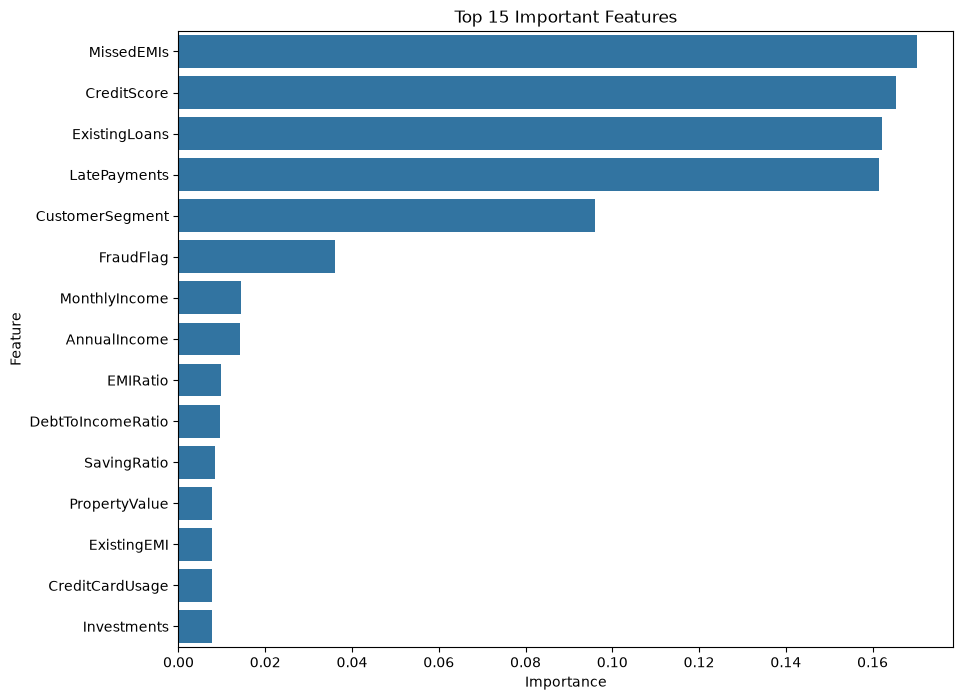

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.show()

In [13]:
mi = mutual_info_classif(x,y)

In [14]:
mi_df = pd.DataFrame({
    "Feature":x.columns,
    "MI Score":mi
})

mi_df.sort_values(
    by="MI Score",
    ascending = False
)

,Feature,MI Score
31,CustomerSegment,0.193011
10,ExistingLoans,0.078404
22,LatePayments,0.078330
23,MissedEMIs,0.076363
15,CreditScore,0.073884
30,FraudFlag,0.066212
6,AnnualIncome,0.013193
32,MonthlyIncome,0.013047
36,DebtToIncomeRatio,0.012965
34,EMIRatio,0.011400
